​
<div style="border-radius:10px;
            border : #015a2c solid;
            background-color:#D7D9DB;
           font-size:110%;
           letter-spacing:0.5px;
            text-align: center">
•
<center><h1 style="padding: 25px 0px; color:#015a4c; font-weight: bold; font-family: Cursive">
Project for Health path   <br><br>💡💡💡💡💡 <br><br> Diabetes Database  </h1></center>
<center><h3 style="padding-bottom: 25px; color:#025b2c; font-weight: bold; font-style:italic; font-family: Cursive">
Using Dataset :Diabetes Database  </h3></center>     
•
</div>

![Diabetes Database](https://user-images.githubusercontent.com/36210723/178112363-36a719ea-2f2f-4131-9ec4-83f6bb2194f1.png)


#  Introduction 👋


**=======================**

### In this notebook I make **Diabetes Dataset - Pima Indians Exploration** by using [dataset](https://www.kaggle.com/datasets/nancyalaswad90/review) which is originally from the National Institute of Diabetes and Digestive and Kidney.
.




## Acknowledgments


**=======================**


When we use this dataset in our research, we credit the authors as :


- **License** : `CC0: Public Domain.`


- **Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press**, and it is published t to reuse in the google research dataset.



###  **The main idea for uploading this dataset is to practice data analysis with my students, as I am working in college and want my student to train our studying ideas in a big dataset, It may be not up to date and I mention the collecting years, but it is  a good resource of data to practice**


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/review/diabetes.csv


# <p style="border-radius:15px;border-style:solid;border-color:lightblue;border-width:3px;background-color:lightblue;padding: 20px;font-family:Verdana;color:#D81F26;font-size:30px;text-align: center;">Import Libraries</p>

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt
import json
import pandas as pd
from pandas import DataFrame
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())

> **We use read function to read a csv file to Import Pima Indians Diabetes Dataset and prepare our analysis**

In [3]:
Analysis_Framework = pd.read_csv("../input/review/diabetes.csv")
dataset_diabetes = pd.DataFrame(Analysis_Framework)


### I will explore first 15 row in the file to see the data type  in it 

In [4]:
dataset_diabetes.head(15)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


> ##  Here we show the number of colums and records

### The purpose is :  I will check the number of rows (observations) and the number of columns (attributes) so I can describe our dataset in proper way in my report in the second question 

In [5]:
print("Our dataset contains: {} rows as observations number and {} columns as attributes number".format(dataset_diabetes.head(10).shape[0],dataset_diabetes.head(10).shape[1]))
dataset_diabetes.head()

Our dataset contains: 10 rows as observations number and 9 columns as attributes number


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


> ##  Here we try to know the type for  each feature

In [6]:
dataset_diabetes.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

> ##  Here we make our assessment of data set  Quality 

### The purpose is :  I will check the missing data, so I can describe our dataset in proper way in my report in the second question 

## First step : Replacing the zero values with NaN so we can evaluating the null values to the  attributes obtained


In [7]:

## ........ I create the funcyion (Nancy which is my name 😄 ) to help me replace zero values with NAN........

Nancy = dataset_diabetes.copy(deep = True)
Nancy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = Nancy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.NaN)

## showing the count of Nans
print(Nancy.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


> ##  Data Acquisition

In [8]:
## import required libraries for the third question
## We used SQL language with panda’s data frame to visualize the statistical measures 
## and matplotlib to show different diagrams for each question.

import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import json
import pandas as pd
from pandas import DataFrame
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())
import matplotlib.pyplot as plt
import plotly.express as px
import plotly
plotly.offline.init_notebook_mode(connected = True)
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split as tts,RandomizedSearchCV,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,plot_confusion_matrix
from random import randint

### 1-	Investigate the relation between Pregnancies and diabetes with display average Pregnancies for patients.

In [9]:
query = '''SELECT avg(Pregnancies) As "average Pregnancies" , "Outcome"  
FROM dataset_diabetes 
Group By "Outcome"   
;'''
q1 = pysqldf(query)
q1

,average Pregnancies,Outcome
0,3.298000,0
1,4.865672,1


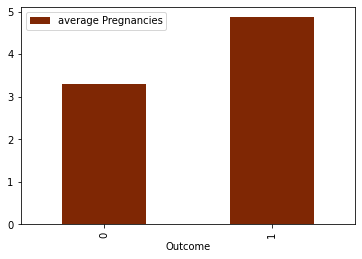

In [10]:
q1.plot.bar(x='Outcome', y='average Pregnancies' , colormap='Oranges_r')

plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:xlabel='Pregnancies', ylabel='Density'>

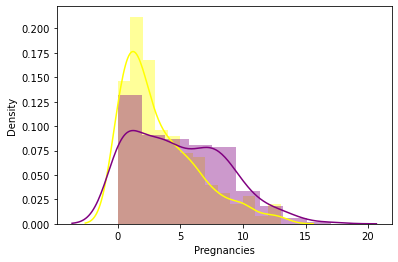

In [11]:
sns.distplot(Nancy[Nancy['Outcome'] == 0]["Pregnancies"], color=  'yellow') #  for the Healthy chart
sns.distplot(Nancy[Nancy['Outcome'] == 1]["Pregnancies"], color= 'purple') # for the Diabetic chart

### 2-	Investigate the relation between BMI and diabetes and average BMI for patients

In [12]:
query = '''SELECT avg(BMI) As "average BMI" , "Outcome"  
FROM dataset_diabetes 
Group By "Outcome"   
;'''
q2 = pysqldf(query)
q2

,average BMI,Outcome
0,30.304200,0
1,35.142537,1


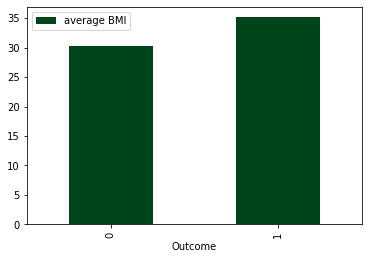

In [13]:
q2.plot.bar(x='Outcome', y='average BMI' , colormap='BuGn_r')

plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:xlabel='BMI', ylabel='Density'>

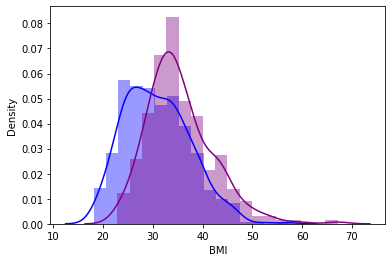

In [14]:
sns.distplot(Nancy[Nancy['Outcome'] == 0]["BMI"], color='blue') #  for the Healthy chart
sns.distplot(Nancy[Nancy['Outcome'] == 1]["BMI"], color='purple') # for the Diabetic chart

### 3-	Investigate the relation between  Glucose and diabetes and average Glucose level for patients.

In [15]:
query = '''SELECT avg(Glucose) As "average Glucose" , "Outcome"  
FROM dataset_diabetes 
Group By "Outcome"   
;'''
q3 = pysqldf(query)
q3

,average Glucose,Outcome
0,109.980000,0
1,141.257463,1


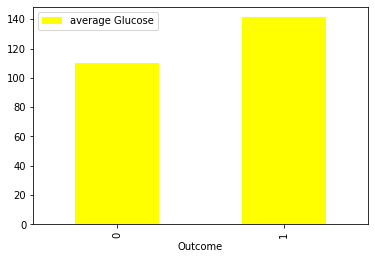

In [16]:
q3.plot.bar(x='Outcome', y='average Glucose' , colormap='gnuplot_r')  

plt.show()

In [17]:
Nancy['Glucose'].fillna(Nancy['Glucose'].median(), inplace = True)
Nancy['BloodPressure'].fillna(Nancy['BloodPressure'].median(), inplace = True)
Nancy['SkinThickness'].fillna(Nancy['SkinThickness'].median(), inplace = True)
Nancy['Insulin'].fillna(Nancy['Insulin'].median(), inplace = True)
Nancy['BMI'].fillna(Nancy['BMI'].median(), inplace = True)

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:xlabel='Glucose', ylabel='Density'>

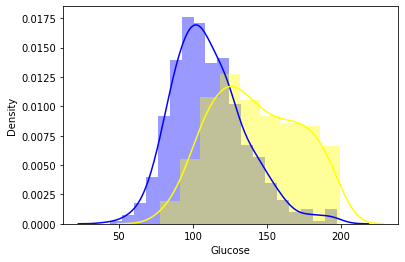

In [18]:
sns.distplot(Nancy[Nancy['Outcome'] == 0]["Glucose"],color='blue' )#  for the Healthy chart
sns.distplot(Nancy[Nancy['Outcome'] == 1]["Glucose"], color='yellow') # for the Diabetic chart

### 4-	Investigate the relation between Insulin and diabetes and average Insulin for patients.

In [19]:
query = '''SELECT avg(Insulin) As "average Insulin" , "Outcome"  
FROM dataset_diabetes 
Group By "Outcome"   
;'''
q4 = pysqldf(query)
q4

,average Insulin,Outcome
0,68.792000,0
1,100.335821,1


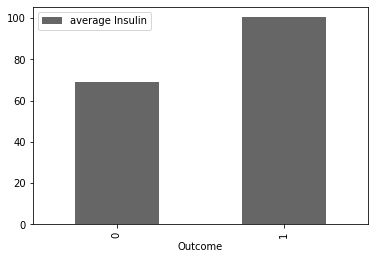

In [20]:
q4.plot.bar(x='Outcome', y='average Insulin' , colormap='Accent_r')

plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:xlabel='Insulin', ylabel='Density'>

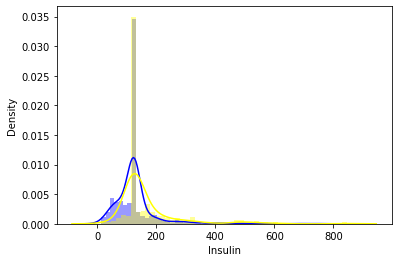

In [21]:
sns.distplot(Nancy[Nancy['Outcome'] == 0]["Insulin"], color='blue') #  for the Healthy chart
sns.distplot(Nancy[Nancy['Outcome'] == 1]["Insulin"], color='yellow')  # for the Diabetic chart

### 5-	Investigate the relation between Blood pressure and diabetes and average Blood pressure for patients.

In [22]:
query = '''SELECT avg(BloodPressure) As "average Blood Pressure" , "Outcome"  
FROM dataset_diabetes 
Group By "Outcome"   
;'''
q5 = pysqldf(query)
q5

,average Blood Pressure,Outcome
0,68.184000,0
1,70.824627,1


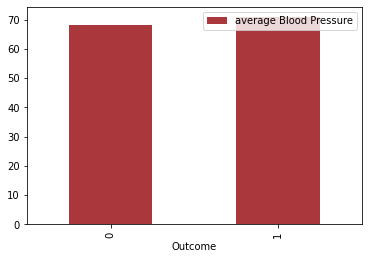

In [23]:
q5.plot.bar(x='Outcome', y='average Blood Pressure' , colormap='vlag_r')

plt.show()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<AxesSubplot:xlabel='BloodPressure', ylabel='Density'>

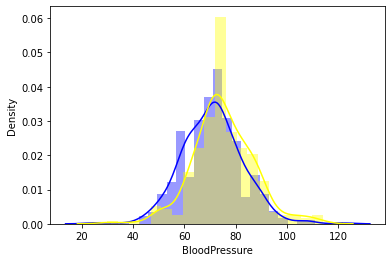

In [24]:
sns.distplot(Nancy[Nancy['Outcome'] == 0]["BloodPressure"], color='blue')#  for the Healthy chart
sns.distplot(Nancy[Nancy['Outcome'] == 1]["BloodPressure"], color='yellow') # for the Diabetic chart

### I use the  below code as example of using numpy to generate some random data, and using matplotlib to visualise it.

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



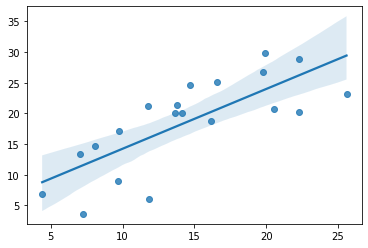

In [25]:
## The site : https://colab.research.google.com/notebooks/charts.ipynb#scrollTo=el13bTbyPRw4

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Generate some random data
num_points = 20
# x will be 5, 6, 7... but also twiddled randomly
x = 5 + np.arange(num_points) + np.random.randn(num_points)
# y will be 10, 11, 12... but twiddled even more randomly
y = 10 + np.arange(num_points) + 5 * np.random.randn(num_points)
sns.regplot(x, y)
plt.show()

![Diabetes Database 111](https://user-images.githubusercontent.com/36210723/178112357-4187610c-c17c-4484-91be-bbf1cfe22812.png)